In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
class SVM:
    def __init__(self,learning_rate=0.001,lambda_param=0.01,n_iters=1000):
        self.lr=learning_rate
        self.lambda_param=lambda_param
        self.n_iters= n_iters
        self.w=None
        self.b=None
    
    def fit(self,X,y):
        n_samples,n_features=X.shape
        
        y_ = np.where(y<=0,-1,1)
        
        #init weight
        self.w=np.random.uniform(0,1,n_features) # Random initialization of weights works best do it using uniform weight initialization
        self.b=0
        
        # Learn the Weights with the update rule
        for _ in range(self.n_iters):
            for idx,x_i in enumerate(X):
                condition= y_[idx] * (np.dot(x_i,self.w)-self.b) >=1
            if condition:
                self.w -= self.lr * (2* self.lambda_param * self.w)
            else:
                self.w -= self.lr * (2* self.lambda_param * self.w - np.dot(x_i,y_[idx]))
                self.b -= self.lr * y_[idx]
            
    def predict(self,X):
        approx= np.dot(X,self.w) - self.b
        return np.sign(approx)
        

Accuracy 0.64
Accuracy 0.915
Accuracy 0.98
Accuracy 0.54
Accuracy 0.98
Accuracy 1.0


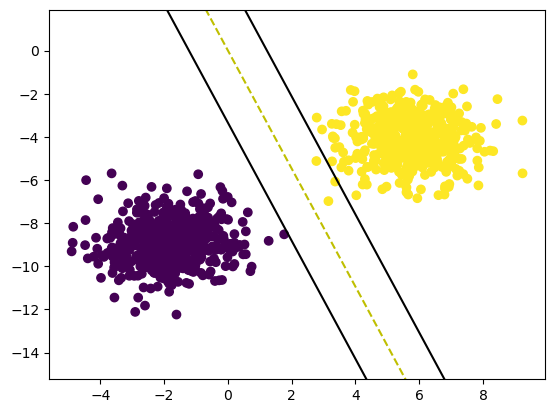

In [24]:
def get_hyperplane_value(x, w, b, offset):
    return (-w[0] * x + b + offset) / w[1]

if __name__ == "__main__":
    auc = []
    
    for i in range(1000):
        X, y = datasets.make_blobs(
            n_samples=1000, n_features=2, centers=2, cluster_std=1.05, random_state=40
        )
        y = np.where(y == 0, -1, 1)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=123
        )

        clf = SVM()
        clf.fit(X_train, y_train)
        predictions = clf.predict(X_test)
        
        if accuracy_score(y_test, predictions) ==1:
            print("Accuracy", accuracy_score(y_test, predictions))
            break
        else:
            auc.append(accuracy_score(y_test, predictions))
        
        print("Accuracy", accuracy_score(y_test, predictions))

    def visualize_svm():
        fig = plt.figure()
        ax = fig.add_subplot(1, 1, 1)
        plt.scatter(X[:, 0], X[:, 1], marker="o", c=y)

        x0_1 = np.amin(X[:, 0])
        x0_2 = np.amax(X[:, 0])

        x1_1 = get_hyperplane_value(x0_1, clf.w, clf.b, 0)
        x1_2 = get_hyperplane_value(x0_2, clf.w, clf.b, 0)

        x1_1_m = get_hyperplane_value(x0_1, clf.w, clf.b, -1)
        x1_2_m = get_hyperplane_value(x0_2, clf.w, clf.b, -1)

        x1_1_p = get_hyperplane_value(x0_1, clf.w, clf.b, 1)
        x1_2_p = get_hyperplane_value(x0_2, clf.w, clf.b, 1)

        ax.plot([x0_1, x0_2], [x1_1, x1_2], "y--")
        ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], "k")
        ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], "k")

        x1_min = np.amin(X[:, 1])
        x1_max = np.amax(X[:, 1])
        ax.set_ylim([x1_min - 3, x1_max + 3])

        plt.show()

    visualize_svm()

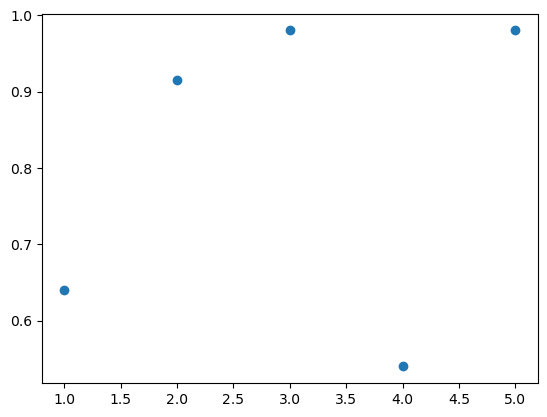

In [28]:
plt.plot(np.arange(1,len(auc)+1,1),auc,'o')